# Config

In [1]:
trace_dir = "./jax_trace"

# Imports

In [2]:
from echofit import EchoFit


/Users/david/Library/Caches/pypoetry/virtualenvs/echofit-W-NSutmR-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Create an echofit instance

In [3]:
fit = EchoFit()


# Data Ingestion

In [4]:
fit.load_csv("xray", "../data/xray.csv")
fit.load_csv("uv", "../data/uv.csv", wavelength=1500)
fit.load_csv("optical", "../data/optical.csv", wavelength=5000)

# Plot raw light curves

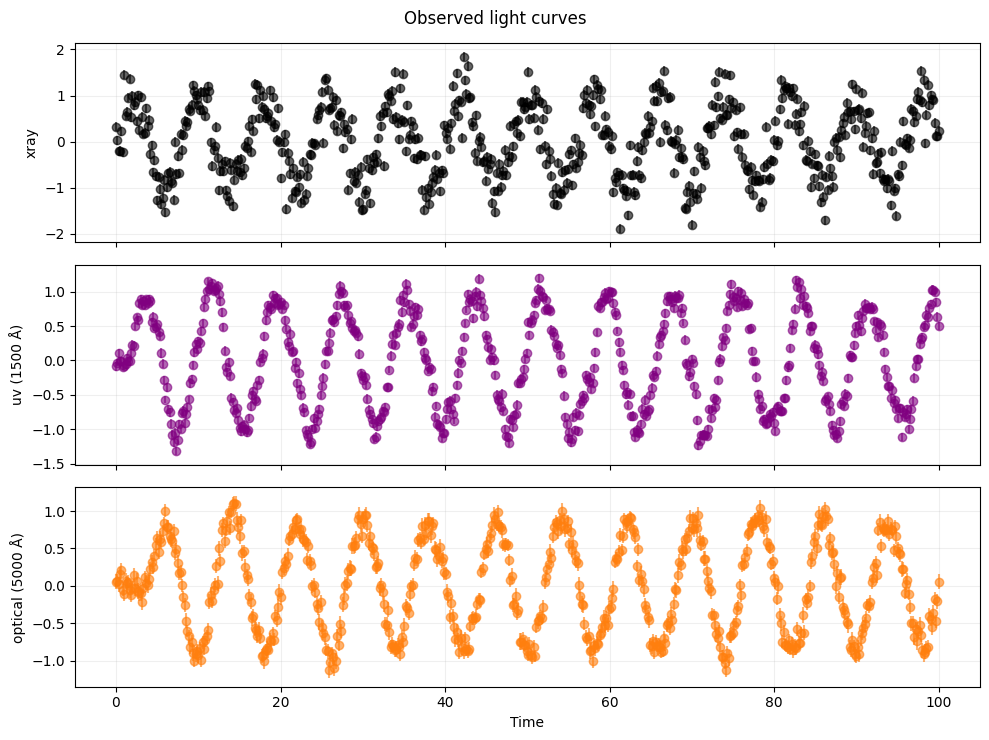

In [5]:
fit.plot_raw_lightcurve_data(normalize=False, errorbars=True, title="Observed light curves")

# Diagnose bugs

In [6]:
import jax.numpy as jnp
import jax.profiler

fit.build_context()
ctx = fit.ctx

print("sigma min:", jnp.min(ctx.sigma_data))
print("sigma max:", jnp.max(ctx.sigma_data))
print("sigma mean:", jnp.mean(ctx.sigma_data))

#sigma min: 0.050020657
#sigma max: 0.109996274
#sigma mean: 0.07744606

sigma min: 0.050020657
sigma max: 0.109996274
sigma mean: 0.07744606


In [7]:
from echofit.model import evaluate_echo_model_matrix

model_dict = evaluate_echo_model_matrix(ctx.cache, ctx.X, (6.0, 0.1, 45.0))

A_blocks = []
for b in ctx.bands:
    A_blocks.append(model_dict[b][ctx.interp_idx[b], :])

A = jnp.concatenate(A_blocks, axis=0)

print("A shape:", A.shape)

print("cond(AᵀA):", jnp.linalg.cond(A.T @ A))

#A shape: (1200, 120)
#cond(AᵀA): 2440629300000.0

A shape: (1200, 120)
cond(AᵀA): 2440629300000.0


# Run

In [ ]:
fit.run_mcmc(num_warmup=5, num_samples=10)

2026-04-06 17:39:45.965689: E external/xla/xla/python/profiler/internal/python_hooks.cc:401] Can't import tensorflow.python.profiler.trace
sample: 100%|██████████| 15/15 [00:07<00:00,  2.11it/s, 1 steps of size 9.76e-03. acc. prob=0.00]
2026-04-06 17:40:08.305699: E external/xla/xla/python/profiler/internal/python_hooks.cc:401] Can't import tensorflow.python.profiler.trace


# Convergence Diagnostics

ValueError: assignment destination is read-only

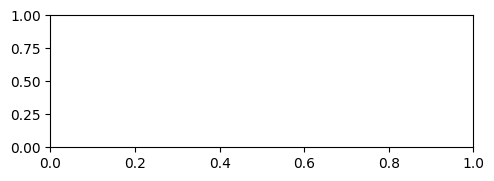

In [9]:
fit.plot_trace()
fit.summary()


# Posterior Dstributions

In [ ]:
fit.plot_posteriors()

# Light curve fits

In [ ]:
fit.plot_lightcurves()

# diagnostics

In [13]:
import time
import jax
from echofit.forward import forward_model

ctx = fit.ctx

params = (6.0, 0.1, 45.0)
sigma_rw = 1.0

C = jax.numpy.ones(len(ctx.bands))
S = jax.numpy.ones(len(ctx.bands))

# warmup (IMPORTANT)
_ = forward_model(
    ctx.cache,
    ctx.X,
    ctx.t_model,
    ctx.interp_idx,
    ctx,
    params,
    sigma_rw,
    C,
    S,
)

jax.block_until_ready(_)

# timed run
t0 = time.time()

for _ in range(10):
    y = forward_model(
        ctx.cache,
        ctx.X,
        ctx.t_model,
        ctx.interp_idx,
        ctx,
        params,
        sigma_rw,
        C,
        S,
    )

jax.block_until_ready(y)

t1 = time.time()

print("avg forward time:", (t1 - t0)/10)

avg forward time: 0.05300607681274414


In [ ]:
import time

import numpyro
from echofit.inference import model

ctx = fit.ctx

m = model(ctx)

# compile warmup
_ = numpyro.handlers.seed(m, jax.random.PRNGKey(0))
_ = numpyro.handlers.trace(_).get_trace()

# timing run
t0 = time.time()
fit.run_mcmc(num_warmup=50, num_samples=50)
t1 = time.time()

print("MCMC time:", t1 - t0)

NameError: name 'model' is not defined